In [1]:
__author__ = 'Sebastian F. Sanchez and LVM team'
__version__ = '20260420'
__datasets__ = ['SDSS-V LVM DAP (DRPVER=1.2.0, DAPVER = 1.2.0.251218, MJD=60191, EXPNUM=4297)']  
__keywords__ = ['Helix nebula','LVM','DR20','model spectra','tutorial']


# LVM DAP output-model generation tutorial

This notebook is a tutorial version of the standalone `gen_output_model.py` workflow, included in the LVMDAP distribution, following the configuration strategy used in the notebook `lvm-dap-gen-out-mod.ipynb` (also nicluded in the LVMDAP distribution), that, instead of reading a separate YAML file, it reads the configuration parameters directly from the `INFO` extension of the DAP FITS file.

The notebook reconstructs the same model products:
- original observed spectra,
- stellar model,
- non-parametric gas model,
- parametric gas model,
- joint model and residual products,

and writes them to a multi-plane FITS file.


## Dependencies

This notebook requires:

- `numpy`
- `scipy`
- `astropy`
- `matplotlib`
- `gdown`
- `ipywidgets`
- `ipympl`


Recommended installation in a conda environment:

```bash
pip install numpy scipy astropy matplotlib import gdown ipywidgets ipympl
```



## 1. Imports and thread control

In [2]:
#
# We use one single thread to avoid problems with the use of multiple threads in some of the used libraries, which can cause problems when running in parallel with multiprocessing.
#
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from pathlib import Path
import numpy as np

from astropy.table import Table,join
from astropy.io import fits
from sdss_access import Access
from pathlib import Path
import os
import matplotlib.pyplot as plt
import math
from pprint import pprint
from astropy.convolution import convolve
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d,median_filter
from numpy.polynomial.legendre import Legendre
import gdown

from sdss_access import Access
access = Access(release='dr20', verbose=True)

## 2. Constants and helper functions

In [3]:

CWD = os.path.abspath(".")
EXT_CHOICES = ["CCM", "CAL"]
EXT_CURVE = EXT_CHOICES[0]
EXT_RV = 3.1
N_MC = 20
F_SCALE = 1e16

def eline(w, W, F, D, V, dap_fwhm=2.354):
    """Return a Gaussian emission-line model evaluated on wavelength array w."""
    c = 299792.00
    w0 = W * (1 + (V / c))
    sigma = D / dap_fwhm
    e1 = np.exp(-0.5 * ((w - w0) / sigma) ** 2)
    return F * e1 / (sigma * ((2 * 3.1416) ** 0.5))

def read_dap_info_config(dap_file):
    """Read the INFO extension of a DAP FITS file and return a dictionary."""
    hdu_dap = fits.open(dap_file)
    tab_config = Table(hdu_dap["INFO"].data)
    hdu_dap.close()

    config = {}
    for row in tab_config:
        key = row["param"]
        val = row["value"]
        config[key] = val
    return config, tab_config

def parse_ny_range(value):
    """Try to interpret ny_range stored in INFO as a tuple/list; otherwise return None."""
    if value is None:
        return None
    if isinstance(value, (tuple, list)):
        return tuple(value)
    try:
        import ast
        parsed = ast.literal_eval(str(value))
        if isinstance(parsed, (tuple, list)) and len(parsed) == 2:
            return tuple(parsed)
    except Exception:
        pass
    return None

def to_float(value, default=None):
    try:
        if hasattr(value, "astype"):
            return value.astype(float)
        return float(value)
    except Exception:
        return default


In [4]:
def replace_nan_inf_with_adjacent_avg(arr):
    # Ensure the input is a numpy array of floats
    arr = np.array(arr, dtype=float)

    # Define a kernel for convolution (4-connected neighbors)
    kernel = np.array([[1, 1, 1, 1, 1, 1, 1],
                       [1, 1, 1, 1, 1, 1, 1],
                       [1, 1, 1, 0, 1, 1, 1],
                       [1, 1, 1, 1, 1, 1, 1],
                       [1, 1, 1, 1, 1, 1, 1]], dtype=float)

    # Handle NaN and inf values
    mask = ~np.isfinite(arr) 
    arr[mask] = 0  # Temporarily set NaN/inf to 0 for convolution

    # Convolve the array with the kernel to get the sum of adjacent values
    convolved_sum = convolve(arr, kernel, boundary='extend', normalize_kernel=False)

    # Convolve the mask to get the count of finite adjacent values
#    convolved_mask = convolve(~mask.astype(float), kernel, boundary='extend', normalize_kernel=False)
    mask_r = ~mask
    convolved_mask = convolve(mask_r.astype(float), kernel, boundary='extend', normalize_kernel=False)
    
    # Compute the average of adjacent values where finite adjacent values are available
    adjacent_avg = convolved_sum / convolved_mask
    adjacent_avg[convolved_mask == 0] = np.nan  # Handle cells with no adjacent finite values

    # Replace NaN and inf values with the computed adjacent average
    arr[mask] = adjacent_avg[mask]

    return arr


def fit_legendre_polynomial(x, y, degree):
    """
    Fits a Legendre polynomial to the given data points.

    Parameters:
    - x (array-like): The x-coordinates of the data points.
    - y (array-like): The y-coordinates of the data points.
    - degree (int): The degree of the Legendre polynomial to fit.

    Returns:
    - Legendre: The fitted Legendre polynomial object.
    - callable: A callable function representing the fitted polynomial.
    """
    # Normalize x to the interval [-1, 1] for Legendre polynomial fitting
    x_min, x_max = np.min(x), np.max(x)
    x_normalized = 2 * (x - x_min) / (x_max - x_min) - 1
    
    # Fit the Legendre polynomial
    coeffs = Legendre.fit(x_normalized, y, degree).convert().coef
    legendre_poly = Legendre(coeffs)
    vals = legendre_poly(2 * (x - x_min) / (x_max - x_min) - 1) 
    return vals


# Hector median_filter copy of SFS median_filter in perl
def my_median_filter(box, x, verbose=False):
    """ Apply a median filter to `x` with box size `box`.

    Parameters
    ----------
    box: int
        Box size of the median filter.
    x: array like
        Array to be filtered.

    Returns
    -------
    array like
        `x` input array filtered
    """
    x = np.asarray(x)
    box_size = 2*box
    box_size = round_up_to_odd(box_size)
    if box_size >= x.size:
        print_verbose(f'[median_filter]: box_size ({box_size}) greater than x.size ({x.size}).', verbose=verbose)
        return x
    val = copy(x)
    for i in range(box, val.size - box):
        val[i] = np.median([x[i - box + j] for j in range(0, 2*box)])
    for i in range(1, box):
        val[i] = np.median([x[j] for j in range(0, 2*i)])
    for i in range(val.size - box, val.size - 1):
        val[i] = np.median([x[i - (val.size - i) + j] for j in range(0, 2*(val.size - i))])
    return val



In [5]:
def read_PT(fitsfile, agcam_coadd, nobad=False, ny_range=None):
    rsshdu = fits.open(fitsfile)

    hdr = rsshdu[0].header
    tab = Table(rsshdu['SLITMAP'].data)
    sci = np.full(len(tab), True)
    mask_bad = (tab['targettype']=='science') & (tab['fibstatus'] == 0) 
    if nobad:
        sci = (tab['targettype']=='science') & (tab['fibstatus'] == 0)
    rsshdu.close()

    # get ra/dec measured from coadd guiders?
    # agcam_coadd = DIR_agcam+mjd+'/'+'lvm.sci.coadd_s'+file_ID+'.fits'
    if os.path.isfile(agcam_coadd):
        agcam_hdu = fits.open(agcam_coadd)
        agcam_hdr = agcam_hdu[1].header
        w = WCS(agcam_hdr)
        cen = w.pixel_to_world(2500,1000)
        racen = cen.ra.deg  #agcam_hdr['RAMEAS']
        deccen = cen.dec.deg #agcam_hdr['DECMEAS']
        pa = agcam_hdr['PAMEAS'] - 180.
        agcam_hdu.close()
    else:
        racen = hdr['POSCIRA']
        deccen = hdr['POSCIDE']
        try:
            pa = hdr['POSCIPA']
        except:
            pa = 0.0
            hdr['POSCIPA'] = pa
    if (pa == None):
        pa = 0.0
        hdr['POSCIPA'] = pa
    if (('ra' in tab.colnames) and ('dec' in tab.colnames)):
        ra_fib = tab['ra']
        dec_fib = tab['dec']
    else:
        if 'fib_ra' in tab.colnames and 'fib_dec' in tab.colnames:
            ra_fib = tab['fib_ra'][sci]
            dec_fib = tab['fib_dec'][sci]
        else:
            ra_fib, dec_fib = make_radec(tab['xpmm'][sci], tab['ypmm'][sci], racen, deccen, pa)
#        ra_fib, dec_fib = make_radec(tab['xpmm'][sci], tab['ypmm'][sci], racen, deccen, pa)
    fiberid=tab['fiberid'][sci]
    exp_fib=[]
    for fibID in fiberid:
        exp_fib.append(str(hdr['exposure'])+'.'+str(fibID))
    tab=Table()
    tab['id']=np.array(exp_fib)
    tab['ra']=ra_fib.data
    tab['dec']=dec_fib.data
    tab['mask']=mask_bad
    tab['fiberid']=fiberid
    tab['exposure']=hdr['exposure']*np.ones(len(tab),dtype=int)
    if (ny_range != None):
        tab=tab[ny_range[0]:ny_range[1]]
#    print(len(sci))
#    tab['mask']=sci
#    print(sci)
    return tab

def read_DAP_file(dap_file,verbose=False):
    dap_hdu=fits.open(dap_file)
    tab_PT=Table(dap_hdu['PT'].data)
    tab_RSP=Table(dap_hdu['RSP'].data)
    tab_COEFFS=Table(dap_hdu['COEFFS'].data)
    tab_PE=Table(dap_hdu['PM_ELINES'].data)
    tab_NPE_B=Table(dap_hdu['NP_ELINES_B'].data)
    tab_NPE_R=Table(dap_hdu['NP_ELINES_R'].data)
    tab_NPE_I=Table(dap_hdu['NP_ELINES_I'].data)
    kel_ext = 0
    try:
        kel_ext = 1
        tab_KEL=Table(dap_hdu['PM_KEL'].data)
    except:
        kel_ext = 0
        print('No PM_KEL extension')

    sig_ext = 0
    try:
        sig_ext = 1
        tab_SIGMA = Table(dap_hdu['ELINES_SIGMA_CHI'].data)
    except:
        sig_ext = 0
        print('No SIGMA_CHI extension')

    #
    # Rename some entries!
    #
    tab_RSP.rename_column('Av','Av_st')
    tab_RSP.rename_column('e_Av','e_Av_st')
    tab_RSP.rename_column('z','z_st')
    tab_RSP.rename_column('e_z','e_z_st')
    tab_RSP.rename_column('disp','disp_st')
    tab_RSP.rename_column('e_disp','e_disp_st')
    tab_RSP.rename_column('flux','flux_st')
    tab_RSP.rename_column('redshift','redshift_st')
    tab_RSP.rename_column('med_flux','med_flux_st')
    tab_RSP.rename_column('e_med_flux','e_med_flux_st')
    tab_RSP.rename_column('sys_vel','vel_st')
    #
    # Parametric elines
    #
    tab_PE.rename_column('flux','flux_pe')
    tab_PE.rename_column('e_flux','e_flux_pe')
    tab_PE.rename_column('disp','disp_pe')
    tab_PE.rename_column('e_disp','e_disp_pe')
    tab_PE.rename_column('vel','vel_pe')
    tab_PE.rename_column('e_vel','e_vel_pe')

    if (kel_ext == 1):
        tab_KEL.rename_column('flux','flux_pek')
        tab_KEL.rename_column('e_flux','e_flux_pek')
        tab_KEL.rename_column('disp','disp_pek')
        tab_KEL.rename_column('e_disp','e_disp_pek')
        tab_KEL.rename_column('vel','vel_pek')
        tab_KEL.rename_column('e_vel','e_vel_pek')
    #
    # id	id_fib	rsp	TEFF	LOGG	META	ALPHAM	COEFF	Min.Coeff	log(M/L)	AV	N.Coeff	Err.Coeff
    #
    tab_COEFFS.rename_column('rsp','id_rsp')
    tab_COEFFS.rename_column('TEFF','Teff_rsp')
    tab_COEFFS.rename_column('LOGG','Log_g_rsp')
    tab_COEFFS.rename_column('META','Fe_rsp')
    tab_COEFFS.rename_column('ALPHAM','alpha_rsp')
    tab_COEFFS.rename_column('COEFF','W_rsp')
    tab_COEFFS.rename_column('Min.Coeff','min_W_rsp')
    tab_COEFFS.rename_column('log(M/L)','log_ML_rsp')
    tab_COEFFS.rename_column('AV','Av_rsp')
    tab_COEFFS.rename_column('N.Coeff','n_W_rsp')
    tab_COEFFS.rename_column('Err.Coeff','e_W_rsp')
    
    tab_DAP=Table(dap_hdu['PT'].data)
    tab_DAP=join(tab_DAP,tab_RSP,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_B,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_R,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_NPE_I,keys=['id'],join_type='left')

    #
    # order parametric emission line table
    #
    mask_elines = (tab_PE['model']=='eline')
    tab_PE = tab_PE[mask_elines]
    
    a_wl = np.unique(tab_PE['wl'])
    I=0
    for wl_now in a_wl:
        if (wl_now>0.0):
            tab_PE_now=tab_PE[tab_PE['wl']==wl_now]
            tab_PE_tmp=tab_PE_now['id','flux_pe','e_flux_pe','disp_pe','e_disp_pe','vel_pe','e_vel_pe']
            for cols in tab_PE_tmp.colnames:        
                if (cols != 'id'):
                    tab_PE_tmp.rename_column(cols,f'{cols}_{wl_now}')
            if (I==0):
                tab_PE_ord=tab_PE_tmp
            else:
                tab_PE_ord=join(tab_PE_ord,tab_PE_tmp,keys=['id'],join_type='left')
            I=I+1        
    tab_DAP=join(tab_DAP,tab_PE_ord,keys=['id'],join_type='left')


    #
    # order parametric emission line table with fixed kinematics
    #
    if (kel_ext == 1):
        mask_elines = (tab_KEL['model']=='eline')
        tab_KEL = tab_KEL[mask_elines]
    
        a_wl = np.unique(tab_KEL['wl'])
        I=0
        for wl_now in a_wl:
            if (wl_now>0.0):
                tab_KEL_now=tab_KEL[tab_KEL['wl']==wl_now]
                tab_KEL_tmp=tab_KEL_now['id','flux_pek','e_flux_pek','disp_pek','e_disp_pek','vel_pek','e_vel_pek']
                for cols in tab_KEL_tmp.colnames:        
                    if (cols != 'id'):
                        tab_KEL_tmp.rename_column(cols,f'{cols}_{wl_now}')
                if (I==0):
                    tab_KEL_ord=tab_KEL_tmp
                else:
                    tab_KEL_ord=join(tab_KEL_ord,tab_KEL_tmp,keys=['id'],join_type='left')
                I=I+1        
        tab_DAP=join(tab_DAP,tab_KEL_ord,keys=['id'],join_type='left')

    #
    # Order COEFFS table
    #
    a_rsp=np.unique(tab_COEFFS['id_rsp'])
    for I,rsp_now in enumerate(a_rsp):
        tab_C_now=tab_COEFFS[tab_COEFFS['id_rsp']==rsp_now]
        tab_C_tmp=tab_C_now['id','Teff_rsp', 'Log_g_rsp', 'Fe_rsp',\
                            'alpha_rsp', 'W_rsp', 'min_W_rsp',\
                            'log_ML_rsp', 'Av_rsp', 'n_W_rsp', 'e_W_rsp']
        for cols in tab_C_tmp.colnames:        
            if (cols != 'id'):
                tab_C_tmp.rename_column(cols,f'{cols}_{rsp_now}')
        if (I==0):
            tab_C_ord=tab_C_tmp
        else:
            tab_C_ord=join(tab_C_ord,tab_C_tmp,keys=['id'],join_type='left')
    tab_DAP=join(tab_DAP,tab_C_ord,keys=['id'],join_type='left')

    if (sig_ext == 1):
        tab_DAP=join(tab_DAP,tab_SIGMA,keys=['id'],join_type='left')
     
    if (verbose==True):
        print('---- ALL Table Columns -----')
        print('-------------------------------')
        print('|        PT                   |')
        print('-------------------------------')
        list_columns(tab_PT.colnames)
        print('----------------------------------')
        print('|        RSP                      |')
        print('----------------------------------')
        list_columns(tab_RSP.colnames)
        print('----------------------------------')
        print('|        PE_ord                   |')
        print('----------------------------------')
        list_columns(tab_PE_ord.colnames)
        if (kel_ext == 1):
            print('----------------------------------')
            print('|        PEK_ord                   |')
            print('----------------------------------')
            list_columns(tab_KEL_ord.colnames)
        print('----------------------------------')
        print('|        NPE_B                    |')
        print('----------------------------------')
        list_columns(tab_NPE_B.colnames,3)
        print('----------------------------------')
        print('|        NPE_R                    |')
        print('----------------------------------')
        list_columns(tab_NPE_R.colnames,3)
        print('----------------------------------')
        print('|        NPE_I                    |')
        print('----------------------------------')
        list_columns(tab_NPE_I.colnames,3)
        print('----------------------------------')
        print('|        C_ord                    |')
        print('----------------------------------')
        list_columns(tab_C_ord.colnames,4)
        if (sig_ext == 1):
            print('----------------------------------')
            print('|        SIGMA_CHI                   |')
            print('----------------------------------')
            list_columns(tab_SIGMA.colnames)
        
    return tab_DAP

def list_columns(obj, cols=4, columnwise=True, gap=2):
    """
    Print the given list in evenly-spaced columns.

    Parameters
    ----------
    obj : list
        The list to be printed.
    cols : int
        The number of columns in which the list should be printed.
    columnwise : bool, default=True
        If True, the items in the list will be printed column-wise.
        If False the items in the list will be printed row-wise.
    gap : int
        The number of spaces that should separate the longest column
        item/s from the next column. This is the effective spacing
        between columns based on the maximum len() of the list items.
    """

    sobj = [str(item) for item in obj]
    if cols > len(sobj): cols = len(sobj)
    max_len = max([len(item) for item in sobj])
    if columnwise: cols = int(math.ceil(float(len(sobj)) / float(cols)))
    plist = [sobj[i: i+cols] for i in range(0, len(sobj), cols)]
    if columnwise:
        if not len(plist[-1]) == cols:
            plist[-1].extend(['']*(len(sobj) - len(plist[-1])))
        plist = zip(*plist)
    printer = '\n'.join([
        ''.join([c.ljust(max_len + gap) for c in p])
        for p in plist])
    print(printer)


class scatter():
    def __init__(self,x,y,ax,size=1,**kwargs):
        self.n = len(x)
        self.ax = ax
        self.ax.figure.canvas.draw()
        self.size_data=size
        self.size = size
        self.sc = ax.scatter(x,y,s=self.size,**kwargs)
        self._resize()
        self.cid = ax.figure.canvas.mpl_connect('draw_event', self._resize)

    def _resize(self,event=None):
        ppd=72./self.ax.figure.dpi
        trans = self.ax.transData.transform
        s =  ((trans((1,self.size_data))-trans((0,0)))*ppd)[1]
        if s != self.size:
            self.sc.set_sizes(s**2*np.ones(self.n))
            self.size = s
            self._redraw_later()

    def _redraw_later(self):
        self.timer = self.ax.figure.canvas.new_timer(interval=10)
        self.timer.single_shot = True
        self.timer.add_callback(lambda : self.ax.figure.canvas.draw_idle())
        self.timer.start()
        


def gamma_scale(flux,gamma):
    return (flux/np.abs(flux))*(np.abs(flux))**gamma

def gamma_scale_abs(flux,gamma):
    return (np.abs(flux))**gamma





In [6]:

def Cardelli_extlaw(l, R_V=3.1):
    """Calculates q(lambda) to the Cardelli, Clayton & Mathis 1989
    reddening law.

    Parameters
    ----------
    l : array like
        Wavelenght vector (Angstroms)

    R_V : float, optional
        Selective extinction parameter (roughly "slope").
        Default is R_V = 3.1.

    Returns
    -------
    array like
        q(lambda) of the reddedning law.
    """
    a = np.zeros(np.shape(l))
    b = np.zeros(np.shape(l))
    F_a = np.zeros(np.shape(l))
    F_b = np.zeros(np.shape(l))
    x = np.zeros(np.shape(l))
    y = np.zeros(np.shape(l))
    q = np.zeros(np.shape(l))
    for i in range(0,len(l)):
        x[i]=10000/l[i]
        y[i]=10000/l[i] - 1.82
    # Far-Ultraviolet: 8 <= x <= 10 ; 1000 -> 1250 Angs
    inter = np.bitwise_and(x >= 8, x <= 10)
    a[inter] = -1.073 - 0.628*(x[inter] - 8.) + 0.137*(x[inter] - 8.)**2 - 0.070*(x[inter] - 8.)**3
    b[inter] = 13.670 + 4.257*(x[inter] - 8.) - 0.420*(x[inter] - 8.)**2 + 0.374*(x[inter] - 8.)**3
    # Ultraviolet: 3.3 <= x <= 8 ; 1250 -> 3030 Angs
    inter =  np.bitwise_and(x >= 5.9, x < 8)
    F_a[inter] = -0.04473*(x[inter] - 5.9)**2 - 0.009779*(x[inter] - 5.9)**3
    F_b[inter] =  0.2130*(x[inter] - 5.9)**2 + 0.1207*(x[inter] - 5.9)**3
    inter =  np.bitwise_and(x >= 3.3, x < 8)
    a[inter] =  1.752 - 0.316*x[inter] - 0.104/((x[inter] - 4.67)**2 + 0.341) + F_a[inter]
    b[inter] = -3.090 + 1.825*x[inter] + 1.206/((x[inter] - 4.62)**2 + 0.263) + F_b[inter]
    # Optical/NIR: 1.1 <= x <= 3.3 ; 3030 -> 9091 Angs ;
    inter = np.bitwise_and(x >= 1.1, x < 3.3)
    a[inter] = 1.+ 0.17699*y[inter] - 0.50447*y[inter]**2 - 0.02427*y[inter]**3 + 0.72085*y[inter]**4 + 0.01979*y[inter]**5 - 0.77530*y[inter]**6 + 0.32999*y[inter]**7
    b[inter] = 1.41338*y[inter] + 2.28305*y[inter]**2 + 1.07233*y[inter]**3 - 5.38434*y[inter]**4 - 0.62251*y[inter]**5 + 5.30260*y[inter]**6 - 2.09002*y[inter]**7
    # Infrared: 0.3 <= x <= 1.1 ; 9091 -> 33333 Angs ;
    inter = np.bitwise_and(x >= 0.3, x < 1.1)
    a[inter] =  0.574*x[inter]**1.61
    b[inter] = -0.527*x[inter]**1.61
    q_l = a + b/R_V
    return q_l

def Charlot_extlaw(l, mu=0.3):
    """
    Returns two-component dust model by Charlot and Fall 2000.

    Parameters
    ----------
    l : array like
        The \lambda wavelength array (in Angstroms).

    mu : float, optional
         Fraction of extinction contributed by the ambient ISM.
         Default value is 0.3.

    Returns
    -------
    array like
        \tau_lambda for t <= 10^7 yr.
    array like
        \tau_lambda for t > 10^7 yr.
    """

    t_lambda_Y = np.power((l/5500.), -0.7)
    t_lambda_O = mu*t_lambda_Y
    return t_lambda_Y, t_lambda_O

def Calzetti_extlaw(l, R_V=4.05):
    """
    Calculates the reddening law by Calzetti et al. (1994).
    Original comments in the .for file:

    q = A_lambda/A_V for Calzetti et al reddening law (formula from hyperz-manual).
    l = lambda, in Angstrons
    x = 1/lambda in 1/microns

    Parameters
    ----------
    l : array like
        Wavelength in Angstroms.
    R_V : float, optional
        Selective extinction parameter (roughly "slope").
        Default value is 4.05.

    Returns
    -------
    array like
        Extinction A_lamda/A_V. Array of same length as l.

    """
    if not isinstance(l, np.ma.MaskedArray):
        l = np.asarray(l, 'float64')
    x = 1e4/l
    q = np.zeros_like(l)
    # UV -> Optical: 1200 -> 6300 Angs
    inter = (l >= 1200.) & (l <= 6300.)
    q[inter] = (2.659/R_V)*(-2.156 + 1.509*x[inter] - 0.198*x[inter]**2 + 0.011*x[inter]**3) + 1.
    # Red -> Infrared
    inter = (l >= 6300.) & (l <= 22000.)
    q[inter] = (2.659/R_V)*(-1.857 + 1.040*x[inter]) + 1.
    # Issue a warning if lambda falls outside 1200->22000 Angs range
    if ((l < 1200.) | (l > 22000.)).any():
        print('[Calzetti_extlaw] WARNING! some lambda outside valid range (1200, 22000.)')
    return q

def calc_extlaw(l, R_V, extlaw=None):
    """
        A wrapper to select which extintion law to use if needed by user.

    Parameters
    ----------
    l : array like
        Wavelength in Angstroms.

    R_V : float
        Selective extinction parameter (roughly "slope").

    extlaw : str {'CCM', 'CAL'}, optional
        Which extinction function to use.
        CCM will call `Cardelli_extlaw`.
        CAL will call `Calzetti_extlaw`.
        Default value is CCM.

    Returns
    -------
    array like
        q(lambda) of the `extlaw` extinction law.
    """
    if (extlaw == 'CCM'):
        return Cardelli_extlaw(l, R_V)
    elif (extlaw == 'CAL'):
        return Calzetti_extlaw(l, R_V)
    else:
        raise ValueError((
            f'[{__name__}]: extlaw {extlaw} not inexistent. Try'
            f'CCM (Cardelli extinction law) or'
            f'CAL (Calzetti extinction law).'
        ))


def spec_apply_dust(wave, flux, AV, R_V=None, extlaw=None):
    """
    Apply the dust extinction law factor to a spectrum `flux` at wavelenghts
    `wave`.

        flux_intrinsic = `flux` * 10^(-0.4 * `AV` * q_l)

    Parameters
    ----------
    wave : array like
        Wavelenghts at restframe.

            (1 + redshift) = `wave` / wave_at_restframe

    flux : array like
        Fluxes to be dust-corrected.

    AV : float or array like
        Dust extinction in mag. If AV is an array, will create
        an (N_AV, N_wave) array of dust spectra.

    R_V : float or None
        Selective extinction parameter (roughly "slope"). Default value 3.1.

    extlaw : str {'CCM', 'CAL'} or None
        Which extinction function to use.
        CCM will call `Cardelli_extlaw`.
        CAL will call `Calzetti_extlaw`.
        Default value is CCM.

    Returns
    -------
    array like
        The `flux` correct by dust extinction.
    """
    if R_V is None:
        R_V = 3.1
    if extlaw is None:
        extlaw = 'CCM'
    q_l = calc_extlaw(wave, R_V, extlaw)
    dust_factor = 10**(-0.4*AV*q_l)
    return flux*dust_factor

def convolve_sigma(flux, sigma, side_box=None):
    """
    Convolves `flux` using a Gaussian-kernel with standard deviation `sigma`.
    The kernel have dimension 2*`side_box` + 1.

    Parameters
    ----------
    flux : array like
        Spectrum to be convolved.
    sigma : float
        Sigma of the Gaussian-kernel.
    N_side: float
        Will define the range size of the Gaussian-kernel.

    Returns
    -------
    array like
        Convolved `flux` by the weights defined by the Gaussian-kernel.
    """
    kernel_function = lambda x: np.exp(-0.5*(((x - side_box)/sigma)**2))
    N = 2*side_box + 1
    kernel = np.array(list(map(kernel_function, np.arange(N))))
    norm = kernel.sum()
    kernel = kernel/norm
    flux_pad = np.pad(flux, len(kernel), mode='edge')
    return np.convolve(flux_pad, kernel, mode='same')[len(kernel):-len(kernel)]
    #return convolve1d(flux, kernel, mode='nearest')


def shift_convolve(wave_obs, wave_in, flux_in, redshift, sigma, sigma_inst=None):
    """
    Shift and convolve spectrum.

    Shift the spectrum `flux_in` at `wave_obs` wavelenghts to `wave_in`
    corrected in redshift. Also convolves the spectrum to `sigma` +
    `sigma_inst`. If `sigma_inst` is None, the shift + convolution of
    `flux_in` is simplier and faster.


    Parameters
    ----------
    wave_obs : array like
        Observed wavelenghts.

    wave_in : array like
        Input wavelengts of SSP models at observed frame.

    flux_in : array like
        Flux in `wave_obs` wavelenghts.

    redshift : float
        Input redshift.

    sigma : float
        Velocity dispersion of data in km/s.

    sigma_inst : float, optional
        Instrumental velocity dispersion in Angstrom.
        Defaults to None.

    Returns
    -------
    array like
        The `flux_in` convolved by `sigma` + `sigma_int` and
        shifted (interpoled) to `wave_in` wavelenghts.

    See also
    --------
    `pyFIT3D.common.stats.convolve_sigma`, `scipy.interpolate.interp1d`
    """



    def conv_interp(w_out, w_in, f_in, sigma=None, box=0, conv=True):
        f = interp1d(
            w_in,
            convolve_sigma(f_in, sigma, 3 if box < 3 else box) if conv else f_in,
            assume_sorted=True, kind='linear', bounds_error=False, fill_value='extrapolate'
        )
        return f(w_out)

    # bring everything to the observed frame
    wave_in_of = wave_in*(1 + redshift)
    dpix_ini = wave_in_of[1] - wave_in_of[0]
    # in the case that the instrumental sigma is not avaible,
    # the shift+convolution process is simplier.
    if sigma_inst is None:
        rsigma = sigma/dpix_ini
        return conv_interp(wave_obs, wave_in_of, flux_in, rsigma, int(3*rsigma))

    dpix = dpix_ini/(1 + np.random.rand())
    # dpix = dpix_ini
    # interpolate flux_in to the new wavelenghts.
    w_min = wave_in_of.min()
    w_max = wave_in_of.max()
    N_sub = (w_max - w_min)/dpix
    wave = w_min + dpix*np.arange(N_sub)
    # resample wave in ln(wavelenght)
    ln_wave = np.log(wave)
    # interpolation factor
    f_fine = __shift_convolve_lnwl_frac__
    ln_dpix = (ln_wave[1] - ln_wave[0])/f_fine
    ln_w_min = ln_wave.min()
    ln_w_max = ln_wave.max()
    N_ln_wave = (ln_w_max - ln_w_min)/ln_dpix
    new_ln_wave = ln_w_min + ln_dpix*np.arange(N_ln_wave)
    # instrumental resolution in pixels
    rsigma_inst = sigma_inst/dpix
    new_wave_inst = np.exp(new_ln_wave)
    #########################################
    # Shift + convolve sigma_inst and sigma #
    #########################################
    # interpolated and sigma_inst convolved flux_in convolved to sigma    
    return conv_interp(
            w_out=wave_obs, w_in=new_wave_inst,

            # interpolated flux_in convolved to sigma_inst.
            f_in=conv_interp(
                w_out=new_wave_inst, w_in=wave,

                # interpolate flux_in to the new wavelenghts.
                f_in=conv_interp(w_out=wave, w_in=wave_in_of, f_in=flux_in, conv=False),

                sigma=rsigma_inst, box=int(6*rsigma_inst), conv=(rsigma_inst > 0.5)
            ),

            sigma=((1 if sigma == 0 else sigma)/__c__)/ln_dpix,
            box=int(5*(500/__c__)/ln_dpix), conv=True,
        )


[WARNING]: <>:52: SyntaxWarning: invalid escape sequence '\l'

[WARNING]: <>:52: SyntaxWarning: invalid escape sequence '\l'

[WARNING]: /tmp/ipykernel_695460/134073198.py:52: SyntaxWarning: invalid escape sequence '\l'
  """



In [7]:
__shift_convolve_lnwl_frac__ = 5  # a.k.a. f_fine in shift_convolve

__mask_elines_window__ = 4  # AA
# Emission Line fine search option
__ELRND_fine_search_option__ = False

__n_Monte_Carlo__ = 20

# speed of light in km/s
__c__ = 299792.458

# convert std to FWHM
__sigma_to_FWHM__ = 2*(2*np.log(2))**0.5

# convert FWHM to sigma
__FWHM_to_sigma__ = 1/__sigma_to_FWHM__

__solar_metallicity__ = 0.02
__solar_luminosity__ = 3.826e33  # erg/s

__selected_extlaw__ = 'CCM'
__selected_R_V__ = 3.1

__selected_half_range_wl_auto_ssp__ = 50
__selected_half_range_sysvel_auto_ssp__ = 100

# Cosmological parameters
__Hubble_constant__ = 71  # km/(s Mpc)
__Omega_matter__ = 0.27
__Omega_Lambda__ = 0.73

__Ha_central_wl__ = 6562.68


## 3. Input files

Locate the input files using `sdss_access` or `Tree`

This notebook first tries to locate the example DR20 Helix dataset using `sdss_access`, then falls back to `Tree`, and only if both fail does it look for local files in the working directory. This makes the tutorial more portable across environments while keeping the dataset definition explicit.


In [ ]:
drpver = "1.2.0"
dapver = '1.2.0.251218' 
DIR_CACHE = 'cache/'
if not os.path.isdir(DIR_CACHE):
    os.mkdir(DIR_CACHE)
DRVER = 'DR20'
DIR_DAP = 'dap_v1.2.0/'
DIR_FIG = 'figs/'
if not os.path.isdir(DIR_FIG):
    os.mkdir(DIR_FIG)
tilegrp = '0011XX'
tileid = '11111'
mjd = '60191'
expnum = '00004297'
mjd = 60191
rsp = 'rsp108'
sn = 'sn20'
i_expnum = int(expnum)

filename = f'lvmSFrame-{expnum}.fits'

# Load the RSP templates

In [9]:
def ensure_files_from_links(dir_cache, file_links):
    dir_cache = Path(dir_cache)
    dir_cache.mkdir(parents=True, exist_ok=True)

    for fname, url in file_links.items():
        out = dir_cache / fname

        if out.exists():
            print(f"Found: {fname}")
            continue

        print(f"Downloading: {fname}")
        gdown.download(url=url, output=str(out), quiet=False)

        if out.exists():
            print(f"OK: {fname}")
        else:
            print(f"FAILED: {fname}")


# Example usage
FOLDER_URL = "https://drive.google.com/drive/folders/1LklOobJpTsgtTlBCswkXNuhmc856XAA4?usp=drive_link"


file_links = {
        "mstar-stlib-cl-108.fits.gz": "https://drive.google.com/uc?id=1RZkdshRNVi69TbVmow5sNdI2kAQokbWO",
        "mstar-stlib-n1235-SN5.fits.gz": "https://drive.google.com/uc?id=1e4vOLBBOSa6n69E4g3a3HMOhZyOPCs3f"
              }  

ensure_files_from_links(DIR_CACHE, file_links)

Found: mstar-stlib-cl-108.fits.gz
Found: mstar-stlib-n1235-SN5.fits.gz


## Load the DRP product,  SFrame

In [10]:
# --------------------------------------------------
# Locate the Helix SFrame file
# --------------------------------------------------

drpver = '1.2.0'
tilegrp = '0011XX'
tileid = '11111'
mjd = '60191'
expnum = '00004297'
kind = 'dap' 
filename = f'lvmSFrame-{expnum}.fits'

path_to_data_file = access.full('lvm_sframe', drpver=drpver, tilegrp=tilegrp, tileid=tileid, mjd=mjd, expnum=expnum)

if not os.path.isfile(path_to_data_file):

    access.remote()
    access.add(product, **kwargs)
    access.set_stream()
    access.commit()
    path_to_data_file = access.full(product, **kwargs)


lvm_file = path_to_data_file


## Load DAP dataproduct, DAP-file

In [11]:
# try:
    ##################################################
    # (1.1) Get the data using the sdss_access pachage
    ##################################################
path_to_data_file = access.full('lvm_dap',  drpver = drpver, dapver = dapver, kind = kind, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
if not os.path.isfile(path_to_data_file):
    access.remote()
    kind = 'dap'    
    access.add('lvm_dap', drpver = drpver, dapver = dapver, kind = kind, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
    access.set_stream()
    access.commit()
    # PATH to lvmDAP file
    path_to_data_file = access.full('lvm_dap',  drpver = drpver, dapver = dapver, kind = kind, tileid = tileid, mjd = mjd, expnum = i_expnum, rspid = rsp, snlevel = sn, daptype = 'dap')
    # print(path_to_data_file)
    # Open data file and print a summary of the Header Data Units
dap_file = path_to_data_file
# except:
#     ################################################################
#     # (1.2) Get the data from a local directory
#     ################################################################
#     dap_file=f'dap-{rsp}-{sn}-{expnum}.dap.fits.gz'
#     dap_file=f'{DIR_DAP}/{dap_file}'



## 4. Function that creates the model based on the results of the DAP analysis

In [12]:
def generate_output_model_from_info(
    lvm_file,
    dap_file,
    label,
    output_path="./",
    flux_scale=(-1, 1),
    debug=False,
    rsp_file=None,
    dump_config=False,
):
    """Rebuild the output model using the configuration stored in the DAP INFO extension."""

    dap_fwhm = 1.0
    output_path = Path(output_path)
    output_path.mkdir(parents=True, exist_ok=True)

    config, tab_config = read_dap_info_config(dap_file)

    if debug:
        print("Configuration recovered from INFO extension")
        pprint(config)

    smooth_size = config.get("smooth_size", 21)
    smooth_size = int(to_float(smooth_size, 21))
    n_leg = config.get("n_leg", 11)
    n_leg = int(to_float(n_leg, 11))
    ny_range = parse_ny_range(config.get("ny_range", None))

    out_file_fit = output_path / f"{label}.output.fits.gz"

    print("##############################################")
    print("# Reading input files...")
    hdu_org = fits.open(lvm_file)
    tab_DAP = read_DAP_file(dap_file, verbose=False)
    tab_DAP.sort("fiberid")
    print(f"# N.Spec. input: {len(tab_DAP)}")
    print("# Done...")
    print("##############################################")

    flux_scale = list(flux_scale)
    if (flux_scale[0] == -1) and (flux_scale[1] == 1) and ("flux_scale_org" in config):
        try:
            fs = config["flux_scale_org"]
            flux_scale[0] = fs[0]
            flux_scale[1] = fs[1]
        except Exception:
            pass

    tab_PT_org = read_PT(lvm_file, "none", ny_range=None)

    if (ny_range is not None) and (ny_range[0] is not None):
        tab_PT_org_range = tab_PT_org[ny_range[0]:ny_range[1]]
        hdu_org["FLUX"].data = hdu_org["FLUX"].data[ny_range[0]:ny_range[1], :]
        hdu_org["FLUX"].data = hdu_org["FLUX"].data[tab_PT_org_range["mask"]]
    else:
        hdu_org["FLUX"].data = hdu_org["FLUX"].data[tab_PT_org["mask"]]

    hdu_org["FLUX"].data = replace_nan_inf_with_adjacent_avg(hdu_org["FLUX"].data)

    wave = hdu_org["WAVE"].data
    ny, nx = hdu_org["FLUX"].data.shape

    model_spectra = np.zeros((9, ny, nx), dtype=np.float32)
    model_spectra[0, :, :] = hdu_org["FLUX"].data

    # --------------------------------------------------
    # Build non-parametric gas model (plane 6)
    # --------------------------------------------------
    np_names, np_waves = [], []
    for td_col in tab_DAP.columns:
        if ((td_col.find("_pe_") == -1) and (td_col.find("_pek_") == -1) and (td_col.find("e_flux_") > -1)):
            l_name = td_col.replace("e_flux_", "")
            w_name = float(l_name.split("_")[-1])
            np_names.append(l_name)
            np_waves.append(w_name)

    print(f"# Number of emission lines in the NP model: {len(np_names)}")
    spec2D_elines = 0.0 * hdu_org["FLUX"].data
    for i, spec2D_now in enumerate(spec2D_elines):
        for name_now, w_now in zip(np_names, np_waves):
            F = tab_DAP[f"flux_{name_now}"][i]
            D = tab_DAP[f"disp_{name_now}"][i]
            V = tab_DAP[f"vel_{name_now}"][i]
            spec2D_now += eline(wave, w_now, F, D, V, dap_fwhm=dap_fwhm)
    model_spectra[6, :, :] = np.copy(spec2D_elines / F_SCALE)

    # --------------------------------------------------
    # Build parametric gas model (plane 7)
    # --------------------------------------------------
    pe_names, pe_waves = [], []
    for td_col in tab_DAP.columns:
        if ((td_col.find("_pe_") > -1) and (td_col.find("_pek_") == -1) and (td_col.find("e_flux_") > -1)):
            l_name = td_col.replace("e_flux_", "")
            w_name = float(l_name.split("_")[-1])
            pe_names.append(l_name)
            pe_waves.append(w_name)

    print(f"# Number of emission lines in the PE model: {len(pe_names)}")
    spec2D_elines = 0.0 * hdu_org["FLUX"].data
    for i, spec2D_now in enumerate(spec2D_elines):
        for name_now, w_now in zip(pe_names, pe_waves):
            F = tab_DAP[f"flux_{name_now}"][i]
            D = tab_DAP[f"disp_{name_now}"][i]
            V = tab_DAP[f"vel_{name_now}"][i]
            spec2D_now += eline(wave, w_now, F, D, V, dap_fwhm=dap_fwhm)
    model_spectra[7, :, :] = np.copy(spec2D_elines / F_SCALE)

    # --------------------------------------------------
    # Stellar parameters and coefficients
    # --------------------------------------------------
    a_redshift = np.array(tab_DAP["redshift_st"])
    a_sigma = np.array(tab_DAP["disp_st"])
    a_AV = np.array(tab_DAP["Av_st"])
    a_flux_st = np.array(tab_DAP["med_flux_st"])

    n_coeffs = 0
    for cols in tab_DAP.columns:
        if cols.find("min_W_rsp_") > -1:
            n_coeffs += 1

    print(f"# N.RSP: {n_coeffs}")
    a_coeffs_input = np.zeros((ny, n_coeffs))
    for i in np.arange(n_coeffs):
        w_id = f"W_rsp_{i}"
        a_coeffs_input[:, i] = np.array(tab_DAP[w_id])

    
    if (rsp_file is None) and ("rsp_file" in config):
        rsp_file = config["rsp_file"]
    sigma_inst = to_float(config.get("sigma-inst", 1.0), 1.0)

    hdu_rsp = fits.open(rsp_file)
    rsp_data = hdu_rsp["SPECTRA"].data
    rsp_wave = (
        hdu_rsp["SPECTRA"].header["CRVAL1"]
        + hdu_rsp["SPECTRA"].header["CDELT1"] * np.arange(0, hdu_rsp["SPECTRA"].header["NAXIS1"])
    )

    print("# Reconstructing stellar model from RSP coefficients")
    for i in range(ny):
        coeffs_input = a_coeffs_input[i, :]
        model_rsp = np.nansum(rsp_data.T * coeffs_input, axis=1)
        model_rsp = shift_convolve(
            wave, rsp_wave, model_rsp, a_redshift[i], a_sigma[i], sigma_inst
        )
        model_spectra[1, i, :] = spec_apply_dust(
            wave, model_rsp * a_flux_st[i] / F_SCALE, a_AV[i], R_V=3.1, extlaw="CCM"
        )
        if (i % 100) == 0:
            print(f"### **** {i}/{ny} *****")

    # --------------------------------------------------
    # Joint model, gas-only products, and residuals
    # --------------------------------------------------
    res_spectra = model_spectra[0, :, :] - model_spectra[1, :, :] - model_spectra[6, :, :]
    l_smooth_spectra = res_spectra * 0.0
    print(f"# smooth_size={smooth_size}, n_leg={n_leg}")
    for idx, res in enumerate(res_spectra):
        smooth = median_filter(res, size=smooth_size)
        l_smooth = fit_legendre_polynomial(wave, smooth, n_leg)
        l_smooth_spectra[idx] = l_smooth

    model_spectra[2, :, :] = model_spectra[1, :, :] + model_spectra[6, :, :] + l_smooth_spectra
    model_spectra[3, :, :] = model_spectra[0, :, :] - (model_spectra[1, :, :] + l_smooth_spectra)
    model_spectra[4, :, :] = model_spectra[0, :, :] - model_spectra[2, :, :]
    model_spectra[5, :, :] = model_spectra[0, :, :] - model_spectra[6, :, :]
    model_spectra[8, :, :] = model_spectra[1, :, :] + model_spectra[7, :, :] + l_smooth_spectra

    # --------------------------------------------------
    # Model patch
    # --------------------------------------------------
    res_spec = model_spectra[0, :, :] - model_spectra[8, :, :]
    smooth_spec = res_spec.copy()
    for idx, res in enumerate(res_spec):
        smooth = median_filter(res, size=21)
        smooth_spec[idx] = smooth

    mask_NP_neg = model_spectra[6, :, :] < 0
    NP_neg = model_spectra[6, :, :].copy()
    NP_neg[~mask_NP_neg] = 0
    NP_pos = model_spectra[6, :, :].copy()
    NP_pos[mask_NP_neg] = 0

    model_spectra[1, :, :] = model_spectra[8, :, :] - model_spectra[7, :, :] + smooth_spec + NP_neg
    model_spectra[2, :, :] = model_spectra[8, :, :] + smooth_spec + NP_neg
    model_spectra[3, :, :] = model_spectra[0, :, :] - model_spectra[1, :, :]
    model_spectra[6, :, :] = NP_pos

    # --------------------------------------------------
    # Write output FITS
    # --------------------------------------------------
    fits_name = str(out_file_fit) if str(out_file_fit).endswith(".gz") else str(out_file_fit) + ".gz"
    h = {
        "CRPIX1": 1,
        "CRVAL1": wave[0],
        "CDELT1": wave[1] - wave[0],
        "NAME0": "org_spec",
        "NAME1": "model_spec",
        "NAME2": "mod_joint_spec",
        "NAME3": "gas_spec",
        "NAME4": "res_joint_spec",
        "NAME5": "no_gas_spec",
        "NAME6": "gas_model_NP",
        "NAME7": "gas_model_PEK",
        "NAME8": "mod_joint_spec_PEK",
        "FILENAME": fits_name,
    }


    print("#############################")
    print("# ALL DONE !!!")
    print("#############################")

    return {
        "wave": wave,
        "tab_DAP": tab_DAP,
        "tab_PT_org": tab_PT_org,
        "tab_config": tab_config,
        "config": config,
        "model_spectra": model_spectra,
        "output_fits": fits_name,
    }


Ensure input files exist

In [13]:
print(os.path.isfile(lvm_file))
print(os.path.isfile(dap_file))

True
True


# Run the scripts that creates the model

In [14]:
label = f"lvm_{tileid}_{mjd}_{expnum}_model"
output_path = f'{DIR_FIG}/{label}.fits.gz'

result = generate_output_model_from_info(
    lvm_file=lvm_file,
    dap_file=dap_file,
    label=label,
    output_path=output_path,
    flux_scale=(-1, 1),
    debug=True,
    rsp_file=Path(DIR_CACHE) / "mstar-stlib-cl-108.fits.gz",
)

Configuration recovered from INFO extension
{'AV': '[0, 0.3, 0.0, 2.5]',
 'N_MC': '30',
 'SN_CUT': '20',
 'SN_CUT_INT': '0.1',
 'auto_redshift': 'True',
 'auto_z_bg': 'True',
 'auto_z_del': '0.0001',
 'auto_z_max': '0.01',
 'auto_z_min': '-0.005',
 'auto_z_sc': 'True',
 'bin_AV': '50',
 'bin_nl': '1',
 'clear_outputs': 'True',
 'config_file': '/home_local/sfsanchez/sda2/code/python/lvmdap/_legacy/auto_ssp_LVM.config',
 'config_yaml': '_legacy/lvm-dap_SD_fast_SN20_ofelia_nosky_hack_cl.yaml',
 'debug': 'False',
 'do_plots': '1',
 'dump_model': 'False',
 'emission_lines_file': '/home_local/sfsanchez/sda2/code/python/lvmdap/_legacy/emission_lines_long_list.LVM',
 'emission_lines_file_long': '/home_local/sfsanchez/sda2/code/python/lvmdap/_legacy/emission_lines_long_list.LVM',
 'emission_lines_file_sky': '/home_local/sfsanchez/sda2/code/python/lvmdap/_legacy/emission_lines_sky.LVM',
 'flux_scale': '[-1, 1]',
 'flux_scale_org': '[-1, 1]',
 'ignore_gas': 'False',
 'in_rss': 'False',
 'input_fm

[WARNING]: /tmp/ipykernel_695460/3618289131.py:25: RuntimeWarning: invalid value encountered in divide
  adjacent_avg = convolved_sum / convolved_mask



# Number of emission lines in the NP model: 215
# Number of emission lines in the PE model: 15
# N.RSP: 108
# Reconstructing stellar model from RSP coefficients
### **** 0/1754 *****
### **** 100/1754 *****
### **** 200/1754 *****
### **** 300/1754 *****
### **** 400/1754 *****
### **** 500/1754 *****
### **** 600/1754 *****
### **** 700/1754 *****
### **** 800/1754 *****
### **** 900/1754 *****
### **** 1000/1754 *****
### **** 1100/1754 *****
### **** 1200/1754 *****
### **** 1300/1754 *****
### **** 1400/1754 *****
### **** 1500/1754 *****
### **** 1600/1754 *****
### **** 1700/1754 *****
# smooth_size=21, n_leg=5
#############################
# ALL DONE !!!
#############################


# 5 Showing the results

Plot the generated model together with the original spectra for a particular fiber (fib)

(6500.0, 6740.0)

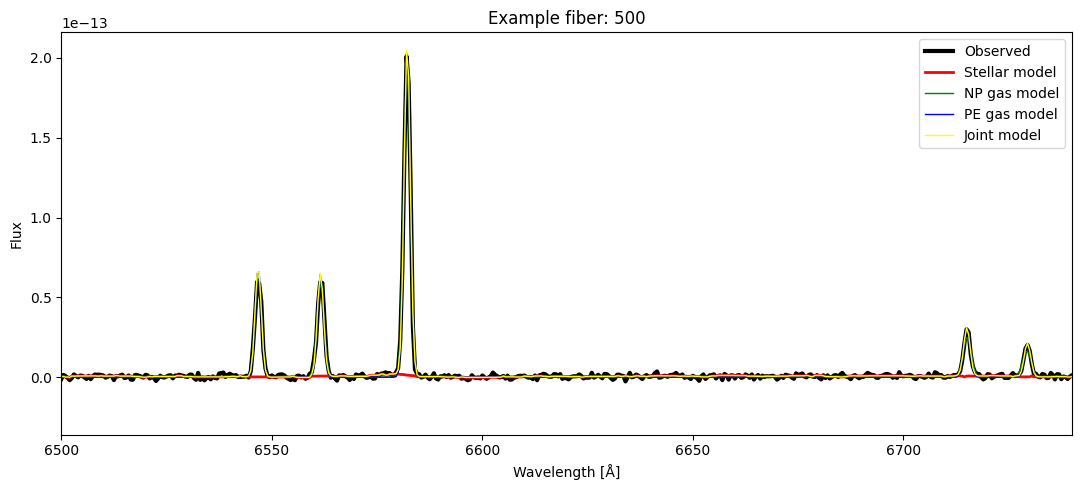

In [15]:
fib = 500
wave = result["wave"]
cube = result["model_spectra"]
%matplotlib inline
plt.figure(figsize=(11, 5))
plt.plot(wave, cube[0, fib, :], label="Observed", lw=3, color="black")
plt.plot(wave, cube[1, fib, :], label="Stellar model", lw=2, color="red")
plt.plot(wave, cube[6, fib, :], label="NP gas model", lw=1, color="green")
plt.plot(wave, cube[7, fib, :], label="PE gas model", lw=1, color="blue")
plt.plot(wave, cube[2, fib, :], label="Joint model", lw=1, color="yellow")

plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title(f"Example fiber: {fib}")
plt.legend()
plt.tight_layout()
plt.xlim(6500, 6740)
#plt.show()

# 6 Plot interactive the model compared to the data

Modified version of the 'lvm_dr20_SFrame_view' notebook that allows to explore the generated model compared to the input data interactively

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML

import matplotlib as mpl
from matplotlib import rcParams as rc
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from astropy.io import fits
from astropy.table import Table, join 


import warnings
warnings.filterwarnings('ignore')

%matplotlib widget
mpl.rcParams['toolbar'] = 'None'

## 6.1 Helper functions for RSS slicing and map visualization

This cell defines a few utility routines:
- `find_nearest`: find the wavelength pixel closest to a requested value,
- `get_slice_img`: collapse the RSS over a narrow wavelength interval,
- `map_plot`: display a scalar quantity on the sky using the fiber positions.

These helpers are the basis of the quick-look exploration of the SFrame: a narrow spectral interval can be converted into a pseudo-image of the field, which is particularly useful for strong nebular lines such as Hα, [O III], or [N II].

In [17]:
%matplotlib widget

rc['toolbar'] = 'None'
def find_nearest(a, a0):
    "Element in nd array `a` closest to the scalar value `a0`"
    idx = np.abs(a - a0).argmin()
    return idx

def get_slice_img(data,wave,w0=6555,w1=6570):
    i0=find_nearest(wave,w0)
    i1=find_nearest(wave,w1)
    #print(i0,i1)
    slice_img=np.mean(data[:,i0:i1],axis=1)*1e15   
    return slice_img

def map_plot(ax,tab_DAP,line='flux_Halpha_6562.85', \
                 vmin=0, vmax=0, title=None, filename='junk',\
                 cmap='Spectral', fsize=5, figs_dir='.',fig_type='png',\
                 gamma=1.0, sf=1.0, tab_pt=None):
    

    
    X=tab_DAP['ra']
    Y=tab_DAP['dec']
    C=tab_DAP[line]    
    xx1=np.max(tab_DAP['ra'])+30/3600
    xx0=np.min(tab_DAP['ra'])+30/3600
    #    xx = ax.get_xlim()
    ax.set_xlim(xx1,xx0)

    if (title== None):
        title=line.replace("_"," ")
        title=line.replace("_"," ")
    if (vmin==vmax):
        vmin=np.nanmin(C)
        vmax=np.nanmax(C)
    norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
    scat=scatter(X, Y, ax, size=sf*35.6/3600, c=C, cmap=cmap, norm=norm)

    ax.set_xlabel('Ra [deg]',fontsize=12)
    ax.set_ylabel('Dec [deg]',fontsize=12)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(scat.sc, cax=cax,label=fr'{title}')
    return scat,ax,cbar,cax


def plot_spec_dap(dir='output/',file='output.m_lvmSCFrame-00006109.fits.gz',\
              name='none',cmap=None,\
              x_min=3600,x_max=9400,y_min=-0.2,y_max=2,text='',\
              file_ssp = 'output/m_lvmSCFrame-00006109',no_st=False,no_model=False,log=False,\
             id_lines=None,output='junk.pdf',c_map='carlos',do_legend=True, insets=None,y0_d=0.5,y1_d=2.5):
    tab_SSP=read_rsp_dap(file_ssp)
    
    if (cmap==None):
        color_cm_now = vel_map_CLC()
        cmap=color_cm_now
    file=dir+'/'+file
    hdu=fits.open(file)
    data=hdu[0].data
    (ny,nx)=data.shape
    i0 = int(nx*0.45)
    i1 = int(nx*0.55)

    data = data / np.median(data[0,i0:i1])
    hdr=hdu[0].header
    crval = hdr['crval1']
    cdelt = hdr['cdelt1']
    crpix = hdr['crpix1']
    (ny,nx) = data.shape
    wave = crval+cdelt*(np.arange(0,nx)-(crpix-1))
    fig = plt.figure(figsize=(19,6)) 
    gs = fig.add_gridspec(nrows=5, ncols=6,  left=0.075, right=0.97, \
                          hspace=0.0, wspace=0.05, bottom=0.15, top=0.99)
    ax0 = fig.add_subplot(gs[:-1, :])
    ax1 = fig.add_subplot(gs[-1:, :], sharex=ax0)   
    ax0.set_xlim(x_min,x_max)
    ax1.set_xlim(x_min,x_max)
    ax0.set_ylim(y_min,y_max)        

    if (c_map=='carlos'):
        colors=color_cm_now(np.linspace(0,1,10))
    else:
        c_colors = mpl.colormaps[c_map].resampled(256)
        colors=c_colors(np.linspace(0,1,10))
        
    colors=['black','maroon','steelblue','darkorange','olive','grey']
    if (no_st==False):
        ax0.plot(wave,data[0,:],color=colors[0],alpha=1.0,linewidth=1.5,label=r'Observed (O$_\lambda$)')
        ax1.plot(wave,data[0,:],color=colors[0],alpha=1.0,linewidth=1.5)#,label=r'Observed (O$_\lambda$)')
        if (no_model==False):
            ax0.plot(wave,data[1,:],color=colors[1],alpha=1.0,label=r'Model (M$_\lambda$)')
            ax1.plot(wave,data[1,:],color=colors[1],alpha=1.0)#,label=r'Model (M$_\lambda$)')
    res = data[0,:]-data[1,:]
    gas_model = data[2,:]-data[1,:]
    ax0.plot(wave,res,color=colors[2],alpha=0.7,\
             label=r'Residual (O$_\lambda$-M$_\lambda$)',linewidth=3)
    if (no_model==False):
        ax0.plot(wave,gas_model,color=colors[3],alpha=0.7,\
                 label=r'Em. lines model')
    
    std_res = np.std(res[2000:2500])
    flux = np.median(data[1,2000:2500])
    ax1.axvspan(5650, 5850, alpha=0.7, color='grey',zorder=10)
    ax1.axvspan(7500, 7700, alpha=0.7, color='grey',zorder=10)
    

    ax0.xaxis.set_minor_locator(MultipleLocator(100))
    handles, labels = ax0.get_legend_handles_labels()
    if (do_legend):
        ax0.legend(handles, labels,loc=(0.8,0.5),frameon=True,handlelength=1.5,\
                   ncol=1,columnspacing=0.15, prop={'size': 22})
    x = np.arange(x_min,1.1*x_max,100)
    y1 = 5+0*x
    y0 = -5+0*x

    if (id_lines != None):
        colors=['darkred','firebrick','indianred']
        mask_lines = (id_lines['wl'].value>=x_min) & (id_lines['wl'].value<x_max)
        tab_elines = id_lines[mask_lines]
        even=0
        for line in tab_elines:
            ax0.text(line['wl'],y_max-0.16*(even+1)*(y_max-y_min),\
                     f"{line['wl']}",color=colors[even],\
                     fontsize='16',horizontalalignment='center',rotation='vertical')
            even=even+1
            if (even>2):
                even=0
        
    if (insets != None):
        for inst in insets:
            axins = ax0.inset_axes(
                [inst[0], inst[1], inst[2], inst[3]],
                xlim=(inst[4], inst[5]), ylim=(inst[6], inst[7]),yticklabels=[])#, xticklabels=[], yticklabels=[])
            if (no_st==False):
                axins.plot(wave,data[0,:],color=colors[0],alpha=1.0,linewidth=1.5,label=r'Observed (O$_\lambda$)')
            if (no_model==False):
                axins.plot(wave,data[1,:],color=colors[1],alpha=1.0,label=r'Model (M$_\lambda$)')
            axins.plot(wave,res,color=colors[2],alpha=0.7,\
                       label=r'Residual (O$_\lambda$-M$_\lambda$)',linewidth=3)
            if (no_model==False):
                axins.plot(wave,gas_model,color=colors[3],alpha=0.7,\
                           label=r'E. lines model')
            ax0.indicate_inset_zoom(axins, edgecolor="black")

        
    ax0.set_ylabel(r'$<$O$_\lambda$/O$_{5500}$$>$', fontsize=23)
    ax0.text(x_min+0.05*(x_max-x_min),y_min+0.85*(y_max-y_min),text,fontsize=21)
    ax1.set_xlabel(r'rest-frame wavelength [\AA]', fontsize=23)
    ax1.set_ylim(y0_d,y1_d)
    if (log==True):
        ax0.set_yscale('log')
    plt.tight_layout()
    fig.savefig(output, transparent=False, facecolor='white', edgecolor='white')#.pdf")

def spec_plot(ax, wave, spec, e_spec=0,
              x_min=3550,x_max=9800,y_min=0,y_max=0):
    
    colors=['black','red','yellow','green','blue','grey']
    spec_plot=ax.plot(wave,spec,color=colors[0],linewidth=1.5,label=r'Observed (O$_\lambda$)')
    if (len(e_spec)>1):
        e_spec_plot=ax.plot(wave,e_spec,color=colors[1],linewidth=2.0,alpha=0.6)#,label=r'Observed (O$_\lambda$)')
    else:
        e_spec_plot=1
    if (y_min==y_max):
        y_min=-0.5*np.median(spec)
        y_max=np.max(spec)
    ax.set_ylim(y_min,y_max)
    ax.set_xlim(x_min,x_max)
    return spec_plot,e_spec_plot


Defining the HTML style for the interactive visualizer

In [18]:
%%html
<style>
div.jupyter-widgets.widget-label {display: none;}
div.ui-dialog-titlebar { display : none; }
.output_wrapper button.btn.btn-default,
.output_wrapper .ui-dialog-titlebar {
  display: none;
}
</style>

## 6.2 Interactive viewer setup

This is the core of the notebook. The cell defines:
- utilities to add fibers to the current selection,
- a function to compute the mean spectrum of the selected fibers,
- global state variables controlling the current wavelength window and colormap,
- and the callback machinery that links the spectral panel with the map panel.

The viewer is designed to let the user click on the map, inspect individual fibers or groups of fibers, and quickly move between spatial and spectral domains.

- Original spectra is shown in black
- RSP model is shown in red
- Emission line model (Parametric Fit), is shown in yellow
- Residuals are shonw in grey


Generating the HDU and tables to use in the visualization

In [19]:
tab_PT = result['tab_DAP']
outmod = result['model_spectra']
(nz,ny,nx) = outmod.shape
WAVE = result['wave']
hdu_0 = fits.PrimaryHDU() 
hdu_FLUX =  fits.ImageHDU(data=outmod[0,:,:],name='FLUX')
hdu_SSP =  fits.ImageHDU(data=outmod[1,:,:],name='RSP')
joinRSS = outmod[2,:,:]# - outmod[7,:,:]+outmod[6,:,:]
hdu_JOIN = fits.ImageHDU(data=joinRSS,name='JOIN')
hdu_ERROR =  fits.ImageHDU(data=outmod[4,:,:],name='ERROR')
hdu_WAVE = fits.ImageHDU(data=WAVE,name='WAVE')
hdu = fits.HDUList([hdu_0,hdu_FLUX,hdu_SSP,hdu_JOIN,hdu_ERROR,hdu_WAVE])

Update the spec_plot function

In [20]:
def spec_plot(ax, wave, spec, e_spec=0,
              x_min=3550,x_max=9800,y_min=0,y_max=0,n_color=0,lw=3):
    
#    colors=['black','grey','red','yellow','olive','grey']
    colors=['black','grey','red','gold','olive','grey']
    if (len(e_spec)>1):
        e_spec_plot=ax.plot(wave,e_spec,color=colors[1+n_color],linewidth=lw/2,alpha=0.7)
    else:
        e_spec_plot=1
    spec_plot=ax.plot(wave,spec,color=colors[0+n_color],linewidth=lw/1.5,label=r'Observed (O$_\lambda$)',alpha=0.8)

    if (y_min==y_max):
        y_min=-0.5*np.median(spec)
        y_max=np.max(spec)
    ax.set_ylim(y_min,y_max)
    ax.set_xlim(x_min,x_max)
    return spec_plot,e_spec_plot

# 6.3 Run the visualizer

Basic use:
- The LVM viewer has two main panels, the spatial viewer (to show maps, left) and the spectral viewer (to show spectra, in the right).
- Click on the map with the left-mouse button to select several fibers.
- The average spectra will be shown in the spectral visualizer.
- Click on the map with the righ-mouse button to remove a selected fiber.
- Move with the central mouse button hold to explore the spectra of the nearest fiber.
- On the spectral viewer in the right, select a region using the left and right-mouse button
  and the map corresponding to the selected wavelength range (average) would be shown in the spatial viewer.
- Use the panels in the bottom to define the spectral range, flux intensity range, or download a snapshot.


In [21]:
%matplotlib widget

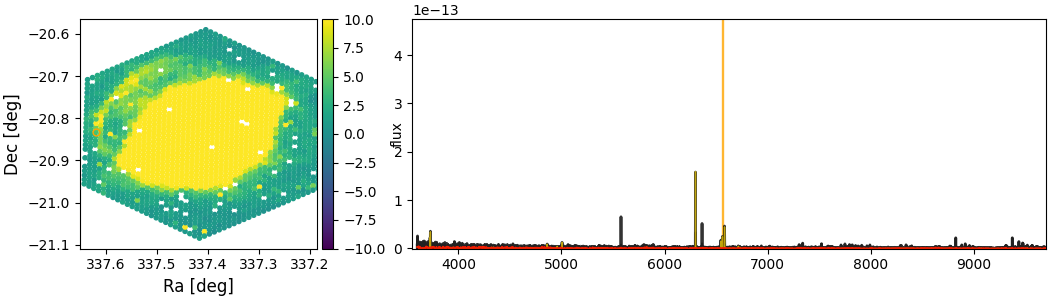

In [22]:
def add_fib(sel_fib,fib):
    sel_fib=np.append(sel_fib,fib)
    sel_fib=np.unique(sel_fib)
    return(sel_fib)
def spec_mean(data,sel_fib):
#    print(len(sel_fib))
    if (len(sel_fib)==1):
        spec=data[sel_fib,:]
        spec=spec.flatten()
    else:
        spec=np.mean(data[sel_fib,:],axis=0)
    return spec


global sp_y_min,sp_y_max,sp_x_min,sp_x_max,fib,cbar,cax0
global cmap,outfile,filetype


outfile='LVMsnap'
filetype='png'
cmap='viridis'
w0=6555
w1=6570
vmin=-10
vmax=10
#fib=int(len(tab_PT)/2)
fib=int(len(tab_PT)*0.3)
slice_img=get_slice_img(hdu['FLUX'].data,hdu['WAVE'].data,w0,w1)
tab_map=tab_PT
tab_map['flux']=slice_img
tab_map=tab_map[tab_map['mask']==1]

list_fib=[]
list_fib.append(fib)
c_fib='orange'
c_fib_now='black'

dw=(hdu['WAVE'].data[1]-hdu['WAVE'].data[0])
fsize=3.5
gamma=1
sf=1
fig = plt.figure(figsize=(10.5, 3), layout="constrained")
fig.canvas.toolbar_visible = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.resizable = False

spec = fig.add_gridspec(1, 7, left=0.05, right=0.75,
                      hspace=0.1, wspace=0.4)
ax0 = fig.add_subplot(spec[0,0:2])
ax1 = fig.add_subplot(spec[0,2:7])


sc,ax_rec,cbar,cax0=map_plot(ax0,tab_map,line='flux', \
                 vmin=vmin, vmax=vmax, title=None, filename='junk',\
             cmap=cmap, fsize=fsize, figs_dir='figs')
m_fib=ax0.plot(tab_map['ra'][fib], tab_map['dec'][fib], \
               marker="o", markersize=5, markeredgecolor=c_fib, markerfacecolor="None")

sel_fib=[]
sel_fib.append(fib)
sel_fib=np.array(sel_fib)
sel_fib = add_fib(sel_fib,fib)
sel_m_fib=[]
sel_m_fib.append(m_fib)

m_spec=spec_mean(hdu['FLUX'].data,sel_fib)
e_m_spec=spec_mean(hdu['ERROR'].data,sel_fib)
rsp_m_spec = spec_mean(hdu['RSP'].data,sel_fib)
join_m_spec = spec_mean(hdu['JOIN'].data,sel_fib)


sp_y_min=-0.5*np.nanmedian(hdu['FLUX'].data[fib,:])
sp_y_max=3*np.nanmax(hdu['FLUX'].data[fib,:])
sp_x_min=3550
sp_x_max=9700
sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max, lw=3)
sp_p1,e_sp_p1 = spec_plot(ax1,hdu['WAVE'].data,rsp_m_spec,join_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max,n_color=2,lw=2) 

mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)


def onclick(event):
    global sp_x_min,sp_x_max,w0,w1,ax0,ax1
    global vmin,vmax,sc,tab_map,sc,gamma,sf,cmap
    global mark,sp_y_min,sp_y_max,dw
            
    #
    # In AX1: Spec
    #
    if ((event.inaxes is ax1) & (event.xdata>ax1.get_xlim()[0]) & \
        (event.xdata<ax1.get_xlim()[1]) & \
        (event.ydata>ax1.get_ylim()[0]) & (event.ydata<ax1.get_ylim()[1])):
        if (event.button==1):
            w0=event.xdata
            if (w0>w1):
                w1=event.xdata+0.5*dw
        if (event.button==3):
            w1=event.xdata
            if (w0>w1):
                w0=event.xdata-0.5*dw
        dw=w1-w0
        try:
            mark.remove()
        except:
            mark_x=1
        mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
        slice_img=get_slice_img(hdu['FLUX'].data,hdu['WAVE'].data,w0,w1)
        tab_map['flux']=slice_img[tab_PT['mask']==1]                
        norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
        scat=scatter(tab_map['ra'], tab_map['dec'], ax0, size=sf*35.6/3600, \
                     c=tab_map['flux'], cmap=cmap, norm=norm)            
        sc_now=ax0.collections[0]
        sc_now.remove()
        w_range_widg.value[0]=np.round(w0,1)
        w_range_widg.value[1]=np.round(w1,1)

def update_m_spec(fib):
    global m_spec,e_m_spec,rsp_m_spec,join_m_spec
    m_spec=hdu['FLUX'].data[fib,:]
    e_m_spec=hdu['ERROR'].data[fib,:] 
    rsp_m_spec = hdu['RSP'].data[fib,:]
    join_m_spec = hdu['JOIN'].data[fib,:]            

def moved_and_pressed(event):
    global sp_x_min,sp_x_max,fib,w0,w1,ax0,ax1
    global vmin,vmax,sc,tab_map,sc,gamma,sf,cmap
    global mark,sp_y_min,sp_y_max,m_fib
    global sel_fib,sel_m_fib
    global m_spec,e_m_spec,rsp_m_spec,join_m_spec
    
    print('button:',event.button)
    if (event.button==1):    
        #act_widg.value='Mouse-B1'
        #
        # In AX0: MAP
        #
        if ((event.inaxes is ax0) & (event.xdata>ax0.get_xlim()[1]) &\
            (event.xdata<ax0.get_xlim()[0]) & \
            (event.ydata>ax0.get_ylim()[0]) & (event.ydata<ax0.get_ylim()[1])):
            dist = np.sqrt((tab_map['ra']-event.xdata)**2+(tab_map['dec']-event.ydata)**2)
            fib_now = np.argmin(dist)
            sel_fib = add_fib(sel_fib,fib_now)
            #            m_fib.pop(0).remove()
            #mark.remove()
            m_fib_now=ax0.plot(tab_map['ra'][fib_now], tab_map['dec'][fib_now], \
               marker="o", markersize=5, markeredgecolor=c_fib_now, markerfacecolor="None")
            
            sel_m_fib.append(m_fib_now)
            [l.remove() for l in ax1.lines]
            update_m_spec(sel_fib)
            sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                                  x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max, lw =3)
            spec_plot(ax1,hdu['WAVE'].data,rsp_m_spec,join_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max,n_color=2, lw=2) 
            #            mark.remove()
            #            mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
            
            act_widg.value=f'Fiber {fib_now} added'
            
    if (event.button==3):    
        #
        # In AX0: MAP
        #


        if ((event.inaxes is ax0) & (event.xdata>ax0.get_xlim()[1]) &\
            (event.xdata<ax0.get_xlim()[0]) & \
            (event.ydata>ax0.get_ylim()[0]) & (event.ydata<ax0.get_ylim()[1])):
            dist = np.sqrt((tab_map['ra']-event.xdata)**2+(tab_map['dec']-event.ydata)**2)
            fib_now = np.argmin(dist)
            sel_fib = np.delete(sel_fib, np.where(sel_fib == fib_now))
            for m_fib_now in sel_m_fib:
                try:
                    m_fib_now.pop(0).remove()
                except:
                    m_fib_now_x=1

            for fib_now in sel_fib:
                m_fib_now=ax0.plot(tab_map['ra'][fib_now], tab_map['dec'][fib_now], \
                                   marker="o", markersize=5, markeredgecolor=c_fib_now, markerfacecolor="None")
                sel_m_fib.append(m_fib_now)
            try:
                m_fib.pop(0).remove()
            except:
                m_fib_x=1
            m_fib=ax0.plot(tab_map['ra'][fib], tab_map['dec'][fib], \
                           marker="o", markersize=5, markeredgecolor=c_fib, markerfacecolor="None")
            [l.remove() for l in ax1.lines]
            update_m_spec(sel_fib)
            sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                                  x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max, lw =3)
            spec_plot(ax1,hdu['WAVE'].data,rsp_m_spec,join_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max,n_color=2, lw=2)  
            act_widg.value=f'Fiber removed'

            
            
    if (event.button==2):
        #
        # In AX0: MAP
        #
        if ((event.inaxes is ax0) & (event.button==2) & (event.xdata>ax0.get_xlim()[1]) &\
            (event.xdata<ax0.get_xlim()[0]) & \
            (event.ydata>ax0.get_ylim()[0]) & (event.ydata<ax0.get_ylim()[1])):
            dist = np.sqrt((tab_map['ra']-event.xdata)**2+(tab_map['dec']-event.ydata)**2)
            fib = np.argmin(dist)
            try:
                m_fib.pop(0).remove()
            except:
                m_fib_x=1
            m_fib=ax0.plot(tab_map['ra'][fib], tab_map['dec'][fib], \
               marker="o", markersize=5, markeredgecolor=c_fib, markerfacecolor="None")
            [l.remove() for l in ax1.lines]
            m_spec=hdu['FLUX'].data[fib,:]
            e_m_spec=hdu['ERROR'].data[fib,:] 
            rsp_m_spec = hdu['RSP'].data[fib,:]
            join_m_spec = hdu['JOIN'].data[fib,:]
            sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                                  x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max, lw =3)
            spec_plot(ax1,hdu['WAVE'].data,rsp_m_spec,join_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max,n_color=2, lw=2)  
            try:
                mark.remove()
            except:
                mark_x=1
            mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
            tx = '%d,%.1f,%.1f' % (fib,event.xdata, event.ydata)
            act_widg.value=f'Spectrum #{fib} shown'
            
        #
        # In AX1: Spec
        #
        if ((event.inaxes is ax1) & (event.button==2) & (event.xdata>ax1.get_xlim()[0]) & \
            (event.xdata<ax1.get_xlim()[1]) & \
            (event.ydata>ax1.get_ylim()[0]) & (event.ydata<ax1.get_ylim()[1])):
            w0=event.xdata-0.5*dw
            w1=event.xdata+0.5*dw
            try:
                mark.remove()
            except:
                mark_x
            mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
            slice_img=get_slice_img(hdu['FLUX'].data,hdu['WAVE'].data,w0,w1)
            tab_map['flux']=slice_img[tab_PT['mask']==1]                
            norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
            scat=scatter(tab_map['ra'], tab_map['dec'], ax0, size=sf*35.6/3600, \
                         c=tab_map['flux'], cmap=cmap, norm=norm)            
            sc_now=ax0.collections[0]
            sc_now.remove()
            w_range_widg.value[0]=np.round(w0,1)
            w_range_widg.value[1]=np.round(w1,1)
            #act_widg.value=f'1fib:{len(fib)}'
#            act_widg.value=f'Wavelength of the map: {w0}'
            

def w_update(change):
    global w0,w1
    w0=change.new[0]
    w1=change.new[1]
    map_update()

def w0_update(change):
    global w0
    w0=change.new
    map_update()
    
    
def cmap_update(change):
    global cmap
    cmap=change.new
    map_update()

def filetype_update(change):
    global filetype
    filetype=change.new
    
def outfile_update(change):
    global outfile,filetype
    outfile=change.new
    
def snap_save(change):
    global outfile,filetype
    plt.savefig(f'{outfile}.{filetype}', transparent=None, dpi='figure', format=None,
            metadata=None, bbox_inches=None, pad_inches=0.1,
            facecolor='auto', edgecolor='auto', backend=None)
    
    act_widg.value=f'{outfile}.{filetype} saved...'
    
def w1_update(change):
    global w1
    w1=change.new
    map_update()
    
def update_flux(change):
    global vmin,vmax
    vmin=change.new[0]
    vmax=change.new[1]
    map_update()
    
def map_update():
    global sp_x_min,sp_x_max,w0,w1,ax0,ax1
    global vmin,vmax,sc,tab_map,sc,gamma,sf,cmap
    global mark,cbar,cax0,scat
    global sp_y_min,sp_y_max,fib,mark
    global m_spec,e_m_spec,rsp_m_spec,join_m_spec
    [l.remove() for l in ax1.lines]
    sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max) 
    spec_plot(ax1,hdu['WAVE'].data,rsp_m_spec,join_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max,n_color=2)  
    mark.remove()
    mark=ax1.fill_betweenx([sp_y_min,sp_y_max], w0, w1, color='orange',alpha=0.7)
    slice_img=get_slice_img(hdu['FLUX'].data,hdu['WAVE'].data,w0,w1)
    tab_map['flux']=slice_img[tab_PT['mask']==1]                
    norm=mpl_colors.PowerNorm(vmin=vmin,vmax=vmax,gamma=gamma)
    scat=scatter(tab_map['ra'], tab_map['dec'], ax0, size=sf*35.6/3600, \
                 c=tab_map['flux'], cmap=cmap, norm=norm)            
    sc_now=ax0.collections[0]
    sc_now.remove()
    cbar = plt.colorbar(scat.sc, cax=cax0)#,fontsize=21)
    w_range_widg.value=(np.round(w0,1),np.round(w1,1))
    
    
def update_spec_range(change):
    global sp_x_min,sp_x_max,sp_y_min,sp_y_max,fib,mark
    global m_spec,e_m_spec,rsp_m_spec,join_m_spec
    sp_x_min=change.new[0]
    sp_x_max=change.new[1]
    [l.remove() for l in ax1.lines]
    sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)
    spec_plot(ax1,hdu['WAVE'].data,rsp_m_spec,join_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max,n_color=2)  
    
   
        
def update_spec_yrange(change):
    global sp_x_min,sp_x_max,sp_y_min,sp_y_max,fib,mark
    global m_spec,e_m_spec,rsp_m_spec,join_m_spec
    sp_y_min=change.new[0]/1e13
    sp_y_max=change.new[1]/1e13
    [l.remove() for l in ax1.lines]
    sp_p,e_sp_p=spec_plot(ax1,hdu['WAVE'].data,m_spec,e_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max)
    spec_plot(ax1,hdu['WAVE'].data,rsp_m_spec,join_m_spec,
                         x_min=sp_x_min,x_max=sp_x_max,y_min=sp_y_min,y_max=sp_y_max,n_color=2) 
    
int_range_xspec = widgets.FloatRangeSlider(
    value=(sp_x_min,sp_x_max), 
    min=sp_x_min, max=sp_x_max, step=hdu['WAVE'].data[1]-hdu['WAVE'].data[0], 
    description='Spec. Wave Range',layout=widgets.Layout(width='85%')
)

int_range_yspec = widgets.FloatRangeSlider(
    value=(-3*np.abs(sp_y_min)*1e13,3*np.abs(sp_y_max)*1e13), 
    min=-3*np.abs(sp_y_min)*1e13, max=3*np.abs(sp_y_max)*1e13, step=1e13*(sp_y_max-sp_y_min)/1000, 
    description='Spec. Flux Range',layout=widgets.Layout(width='85%')
)


int_range_flux = widgets.FloatRangeSlider(
    value=(vmin,vmax), 
    min=-2*np.abs(vmin), max=10*vmax, step=(vmax-vmin)/100,
    description='Flux Range',layout=widgets.Layout(width='90%')
)

w_range_widg = widgets.FloatRangeSlider(
    value=(w0,w1), 
    min=sp_x_min, max=sp_x_max, step=hdu['WAVE'].data[1]-hdu['WAVE'].data[0], 
    description='Wave Map',layout=widgets.Layout(width='95%')
)


act_widg=widgets.Text(
    value='None',
    description='Action:',
    disabled=False,layout=widgets.Layout(width='60%')#,margin='0 0 0 0')
)


cmap_widg=widgets.Dropdown(
    options=plt.colormaps(),
    value=cmap,
    description='cmap:',
    disabled=False,layout=widgets.Layout(width='30%')
)

filetype_widg=widgets.Dropdown(
    options=['png','pdf'],
    value='png',
    description='type:',
    disabled=False,layout=widgets.Layout(width='30%')
)

outfile_widg=widgets.Text(
    value='LVMsnap',
    description='outfile:',
    disabled=False,layout=widgets.Layout(width='50%')#,margin='0 0 0 0')
)

snap_button = widgets.Button(description="Save File")

int_range_xspec.observe(update_spec_range, 'value')
            
int_range_yspec.observe(update_spec_yrange, 'value')
int_range_flux.observe(update_flux, 'value')
w_range_widg.observe(w_update, 'value')

cmap_widg.observe(cmap_update,'value')
filetype_widg.observe(filetype_update,'value')
outfile_widg.observe(outfile_update,'value')

snap_button.on_click(snap_save)

cid_click = fig.canvas.mpl_connect('button_press_event', onclick)
cid_hold = fig.canvas.mpl_connect('motion_notify_event', moved_and_pressed)

UBox = widgets.HBox([w_range_widg],
                    layout=widgets.Layout(width='100%', margin='0 0 0 0', align_items='stretch'))

LBox = widgets.VBox([int_range_xspec, int_range_yspec, act_widg],
                    layout=widgets.Layout(width='60%', margin='0 0 0 0'))

MBox = widgets.HBox([cmap_widg],
                    layout=widgets.Layout(width='100%', margin='0 0 0 0', align_items='stretch'))

DBox_buttons = widgets.HBox([outfile_widg, filetype_widg, snap_button])

RBox = widgets.VBox([int_range_flux, MBox, DBox_buttons],
                    layout=widgets.Layout(width='60%', margin='0 0 0 0', align_items='stretch'))

main_controls = widgets.HBox([RBox, LBox])
full_ui = widgets.VBox([fig.canvas, UBox, main_controls])

display(full_ui)



### About this notebook

This notebook was created to explore the gen_output_model.py workflow included in the LVMDAP distribution.

**Authors**: Sebastian F. Sanchez and the LVM team

**Last Update**: 2026 April 23

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.